In [1]:
import pandas as pd
import numpy as np

In [3]:
# Load dataset with 'latin1' encoding
df = pd.read_csv("/content/Sample_-_Superstore[1].csv", encoding='latin1')

# Preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Shape of dataset
df.shape

# Column names
df.columns

# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
df = df.drop_duplicates()

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [8]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')

In [9]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

In [10]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [11]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Order Year,Order Month,Profit Margin
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,12.031393
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,-275.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,7.500000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,27.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,36.250000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,50.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,46.675435


In [12]:
df.to_csv("Cleaned_Superstore_Data.csv", index=False)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

print(" KEY PERFORMANCE INDICATORS ")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Overall Profit Margin: {profit_margin:.2f}%")

 KEY PERFORMANCE INDICATORS 
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Average Order Value: $458.61
Overall Profit Margin: 12.47%


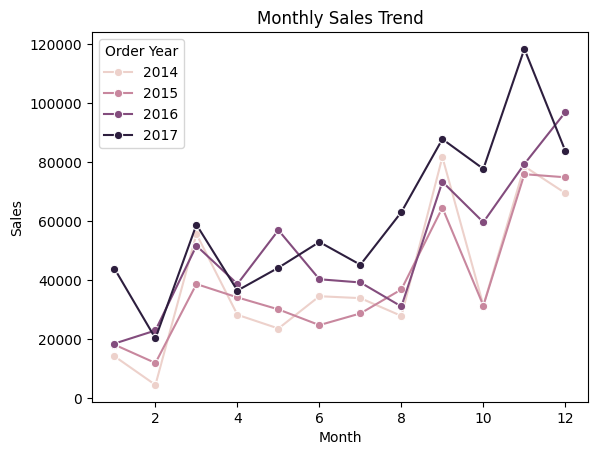

In [14]:
sales_trend = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()

plt.figure()
sns.lineplot(data=sales_trend, x='Order Month', y='Sales', hue='Order Year', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

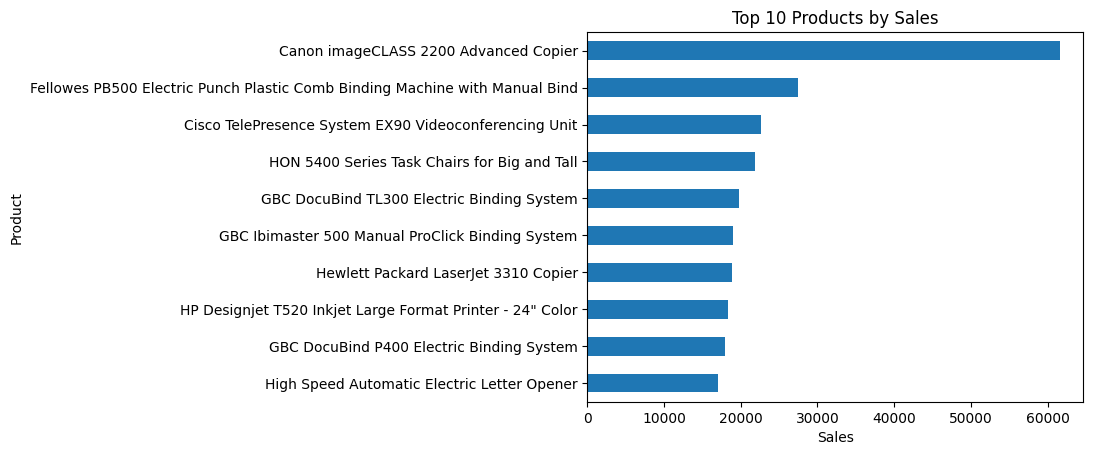

In [15]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='barh')
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

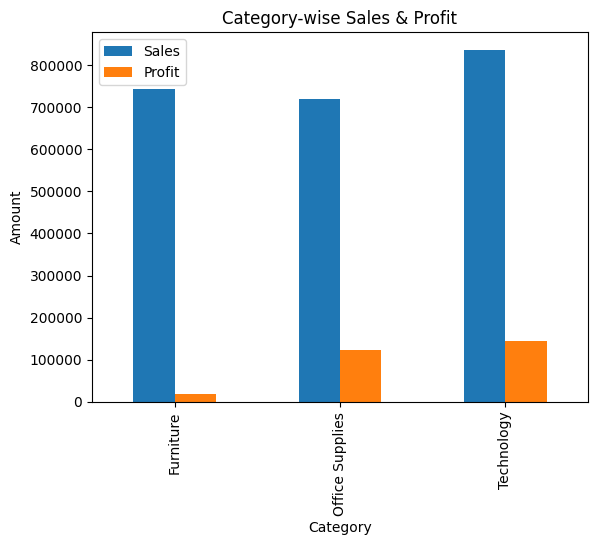

In [16]:
category_perf = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

category_perf.plot(x='Category', kind='bar')
plt.title("Category-wise Sales & Profit")
plt.ylabel("Amount")
plt.show()

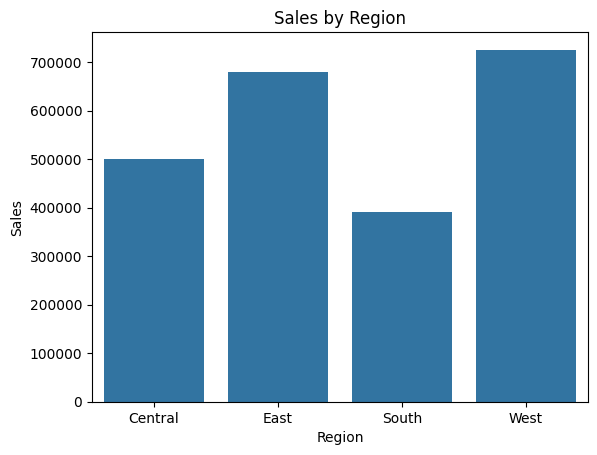

In [17]:
region_perf = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure()
sns.barplot(data=region_perf, x='Region', y='Sales')
plt.title("Sales by Region")
plt.show()

now creating dashboard

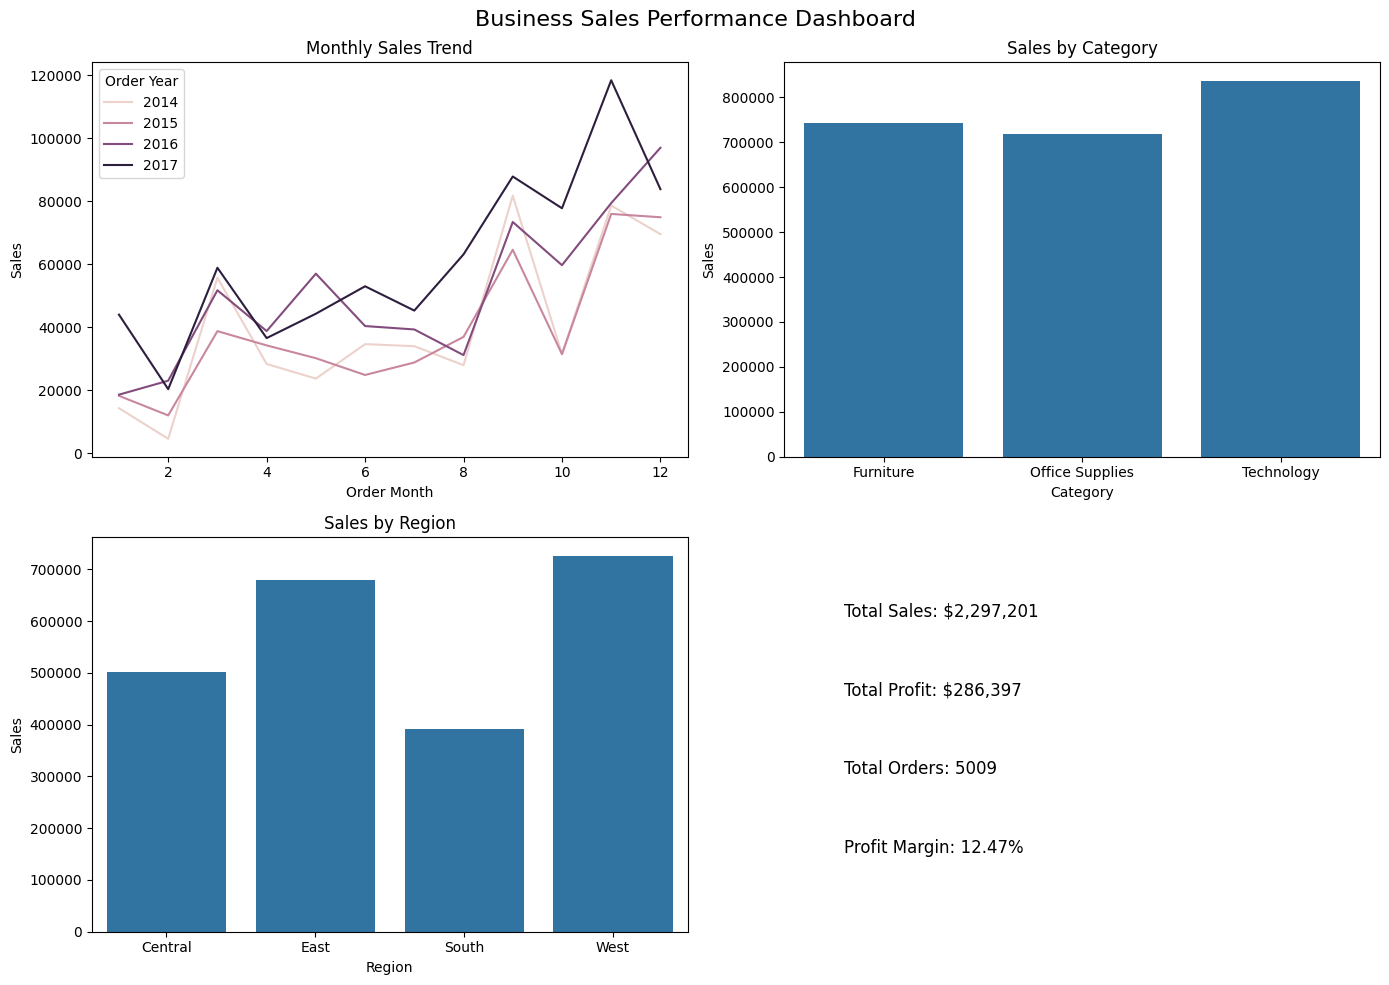

In [18]:
plt.figure(figsize=(14, 10))


plt.subplot(2, 2, 1)
sns.lineplot(data=sales_trend, x='Order Month', y='Sales', hue='Order Year')
plt.title("Monthly Sales Trend")


plt.subplot(2, 2, 2)
sns.barplot(data=category_perf, x='Category', y='Sales')
plt.title("Sales by Category")


plt.subplot(2, 2, 3)
sns.barplot(data=region_perf, x='Region', y='Sales')
plt.title("Sales by Region")


plt.subplot(2, 2, 4)
plt.axis('off')
plt.text(0.1, 0.8, f"Total Sales: ${total_sales:,.0f}", fontsize=12)
plt.text(0.1, 0.6, f"Total Profit: ${total_profit:,.0f}", fontsize=12)
plt.text(0.1, 0.4, f"Total Orders: {total_orders}", fontsize=12)
plt.text(0.1, 0.2, f"Profit Margin: {profit_margin:.2f}%", fontsize=12)

plt.suptitle("Business Sales Performance Dashboard", fontsize=16)
plt.tight_layout()
plt.show()